In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


---
## Task 1 — Exploratory Data Analysis (EDA)

### 1.1 Load Dataset & Shape

In [2]:
df = pd.read_csv('car_price.csv')
df.columns = [c.strip().lower() for c in df.columns]

print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 72435
Columns: 10


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


### 1.2 Feature Types

In [3]:
numerical   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical features  :', numerical)
print('Categorical features:', categorical)
print()
print(df.dtypes)

Numerical features  : ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
Categorical features: ['model', 'transmission', 'fueltype', 'make']

model            object
year            float64
price           float64
transmission     object
mileage         float64
fueltype         object
tax             float64
mpg             float64
enginesize      float64
make             object
dtype: object


### 1.3 Missing Values

In [4]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
missing_df

,Count,Percentage (%)
transmission,3623,5.0
year,3622,5.0
fueltype,3622,5.0
mileage,3622,5.0
enginesize,3622,5.0
model,3621,5.0
price,3621,5.0
tax,3621,5.0
mpg,3621,5.0
make,3621,5.0


### 1.4 Price Distribution

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


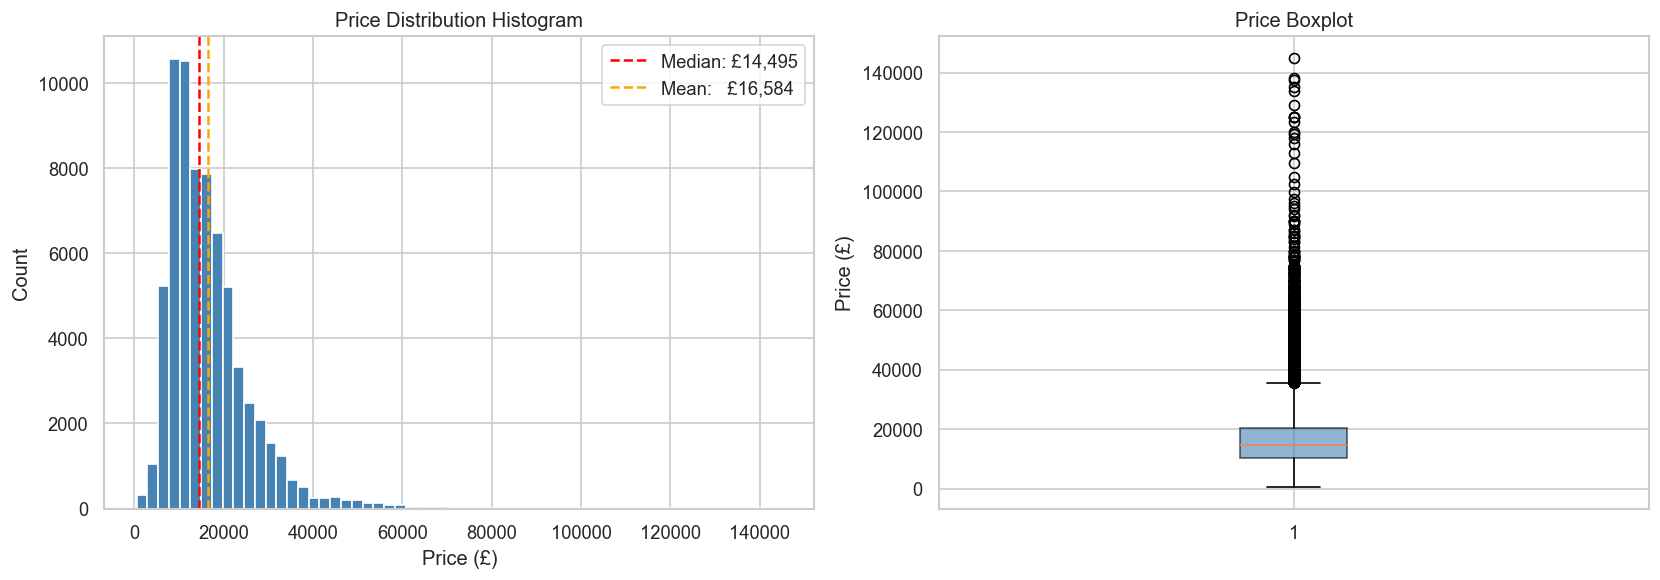

In [5]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['price'].median(), color='red',    linestyle='--',
                label=f'Median: \u00a3{df["price"].median():,.0f}')
axes[0].axvline(df['price'].mean(),   color='orange', linestyle='--',
                label=f'Mean:   \u00a3{df["price"].mean():,.0f}')
axes[0].set_title('Price Distribution Histogram')
axes[0].set_xlabel('Price (\u00a3)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['price'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (\u00a3)')

plt.tight_layout()
plt.show()

### 1.5 Relationship with numerical features

C:\Users\ABDULLUH\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


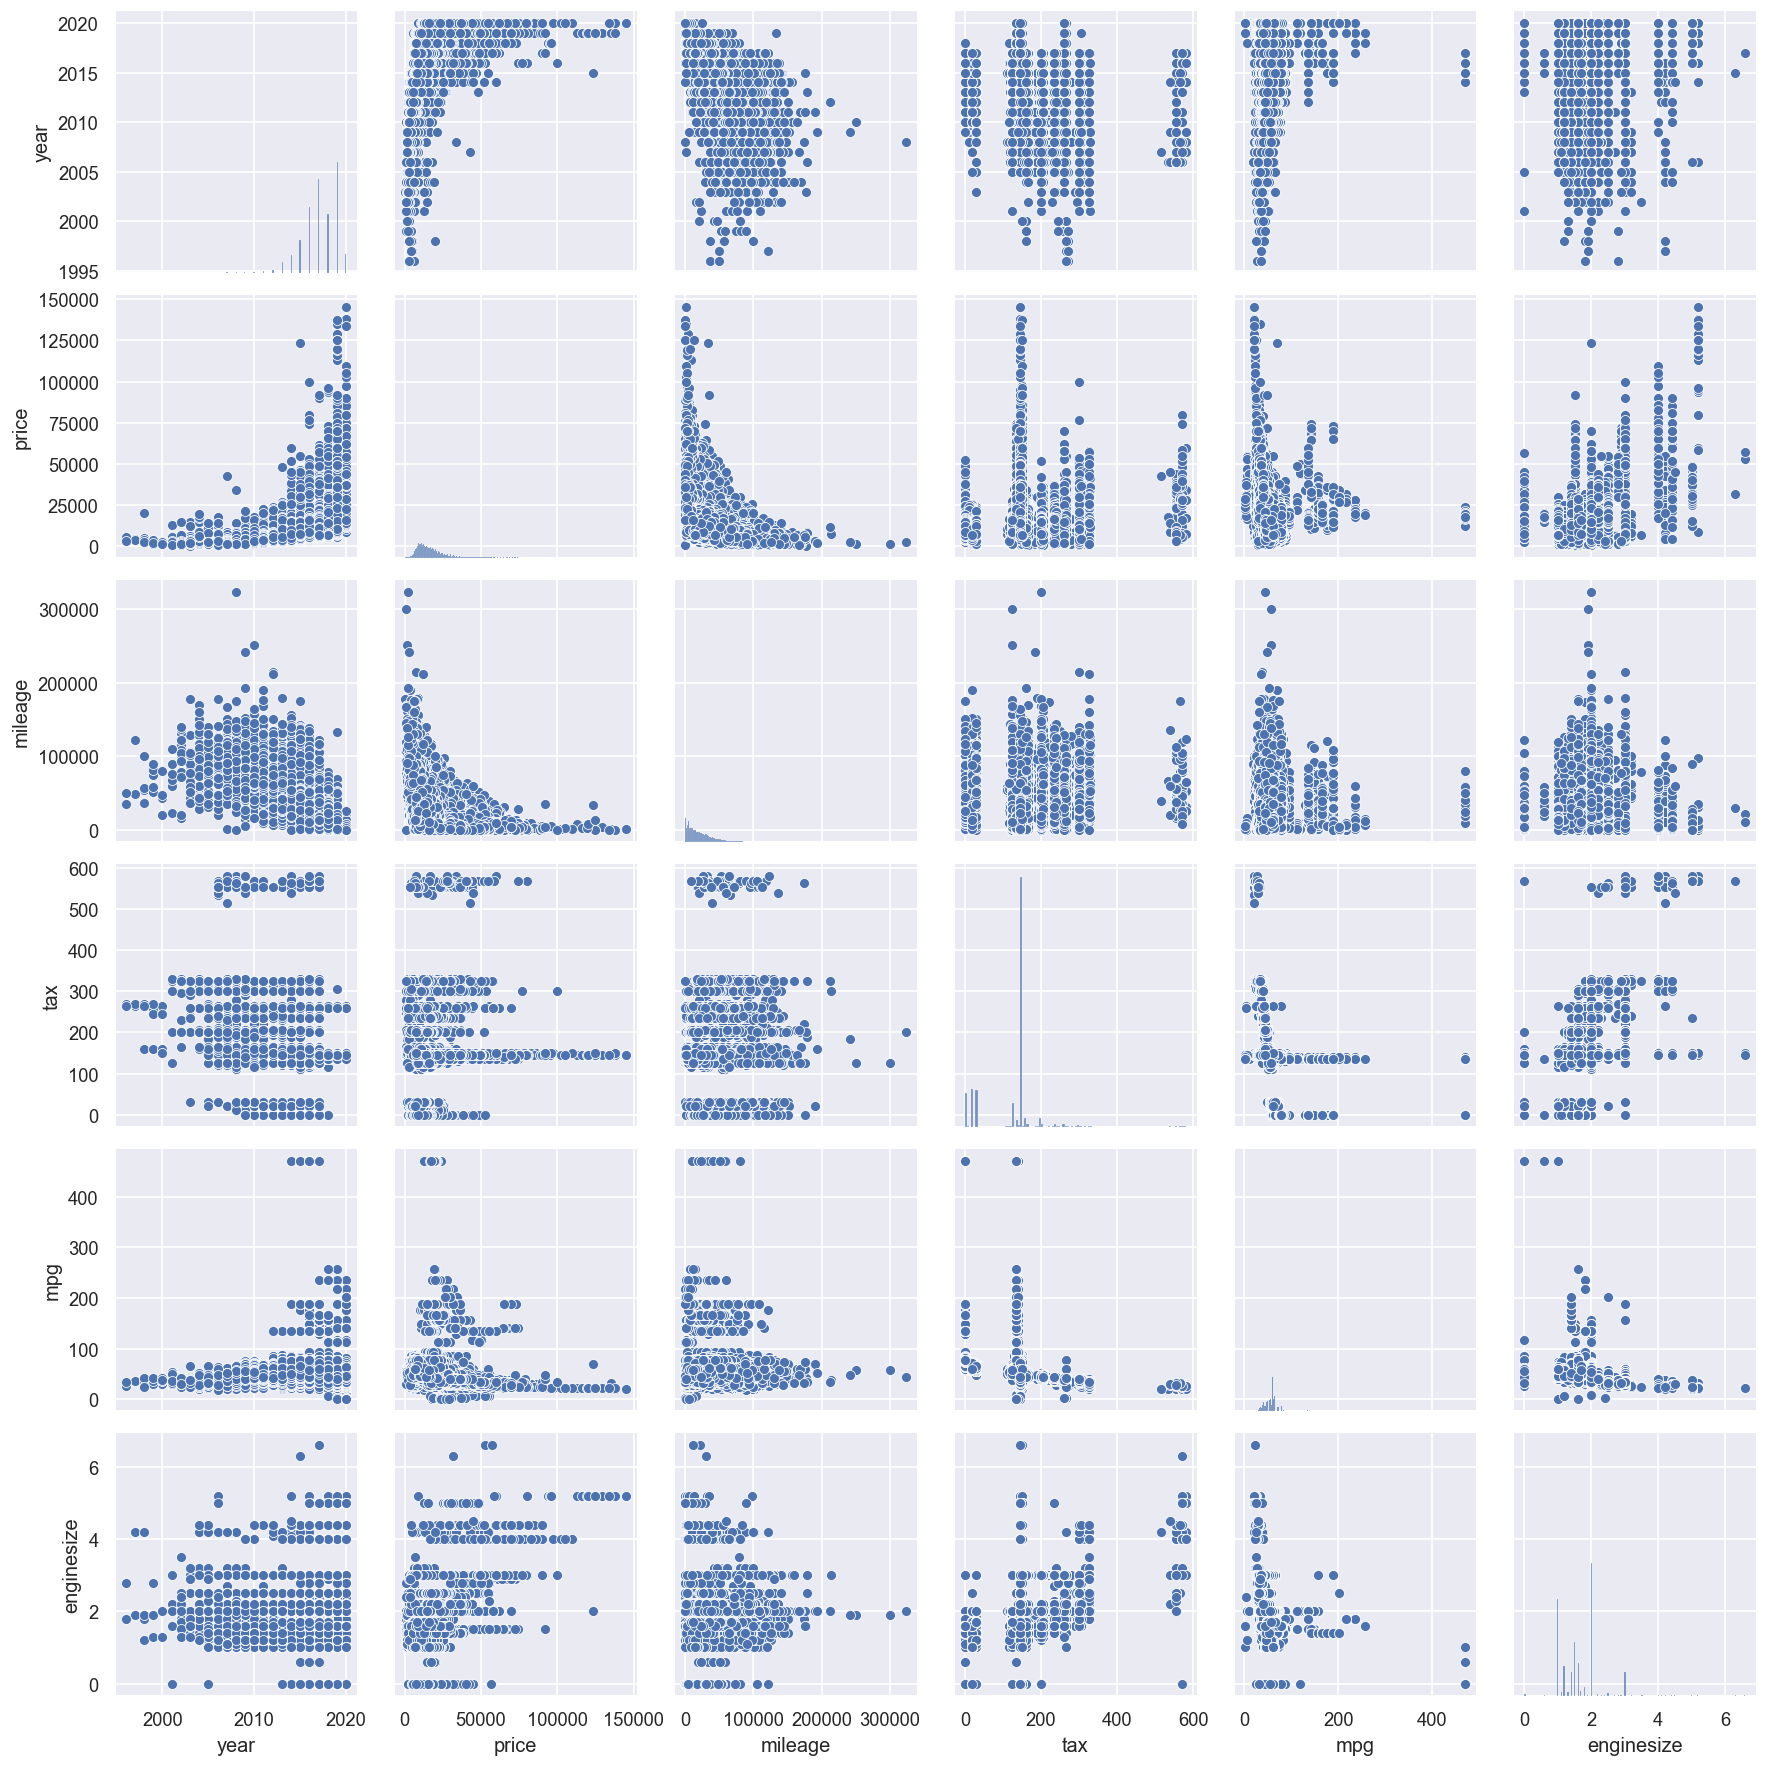

In [6]:
#pairplot
sns.set()
num_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
sns.pairplot(df[num_cols], size = 2.5)
plt.show();

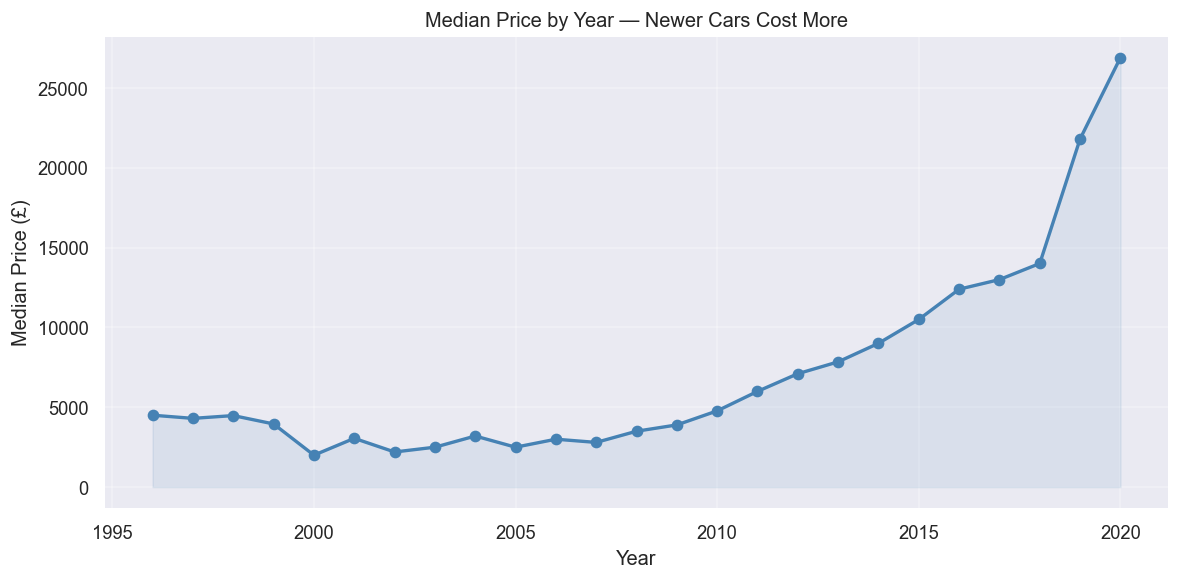

In [7]:
# Newer cars are consistently priced higher — confirms year as a key predictor.
year_price = df.groupby('year')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(year_price['year'], year_price['price'],
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(year_price['year'], year_price['price'], alpha=0.1, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Median Price (£)')
plt.title('Median Price by Year — Newer Cars Cost More')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Correlation with price:
price         1.000000
enginesize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


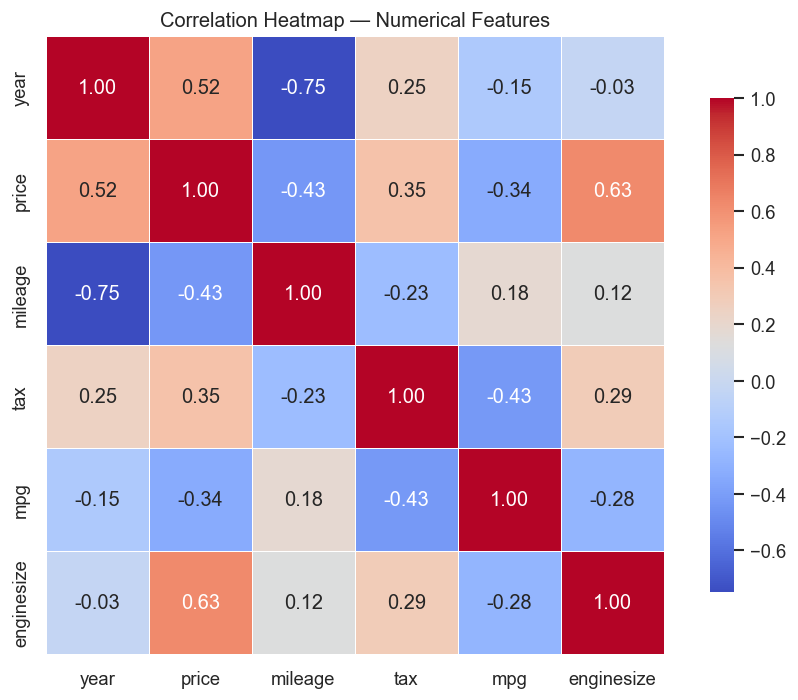

In [8]:
corr = df[num_cols].corr()

print('Correlation with price:')
print(corr['price'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

Based on the correlation analysis, `engineSize` and `year` are the most significant features with a strong positive impact on price, meaning newer cars with larger engines tend to be more expensive. `mileage` shows a negative correlation, acting as the primary factor that drives the price down as it increases.

### 1.6 Relationship with categorical features

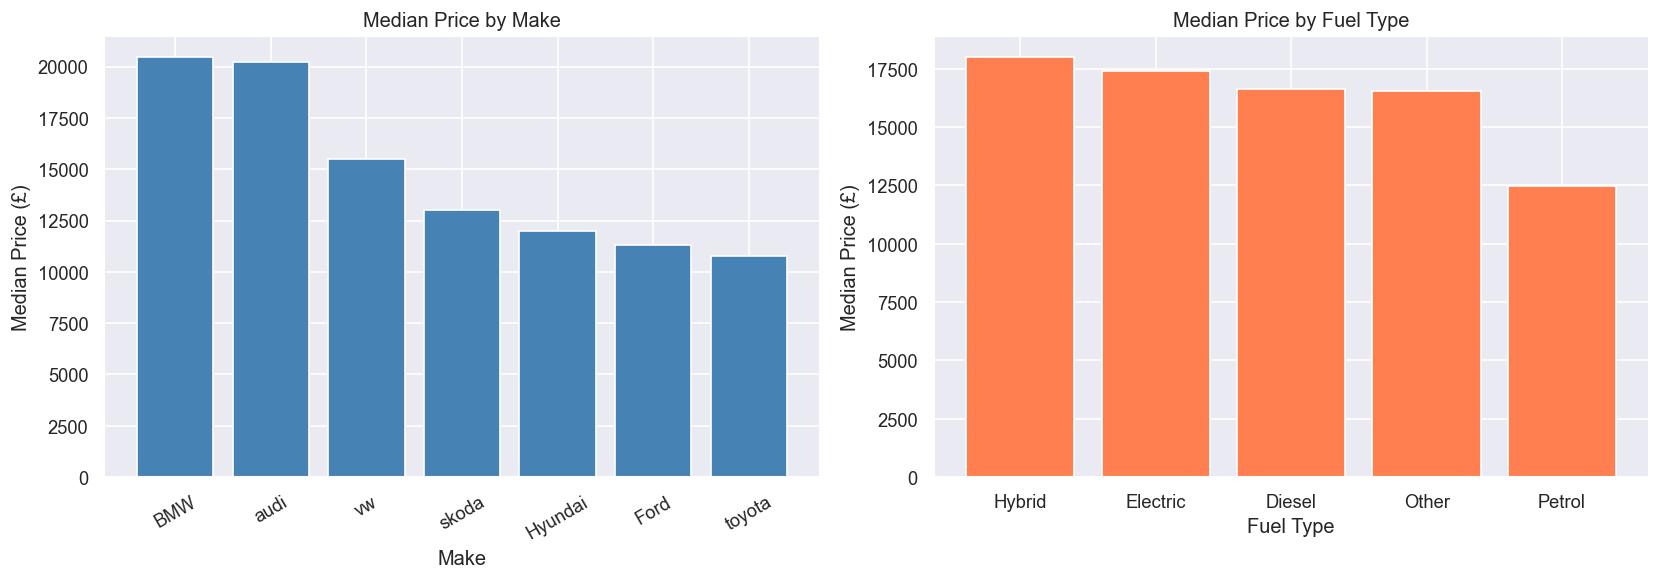

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

make_price = df.groupby('make')['price'].median().sort_values(ascending=False)
axes[0].bar(make_price.index, make_price.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Make')
axes[0].set_xlabel('Make')
axes[0].set_ylabel('Median Price (\u00a3)')
axes[0].tick_params(axis='x', rotation=30)

fuel_price = df.groupby('fueltype')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color='coral', edgecolor='white')
axes[1].set_title('Median Price by Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price (\u00a3)')

plt.tight_layout()
plt.show()

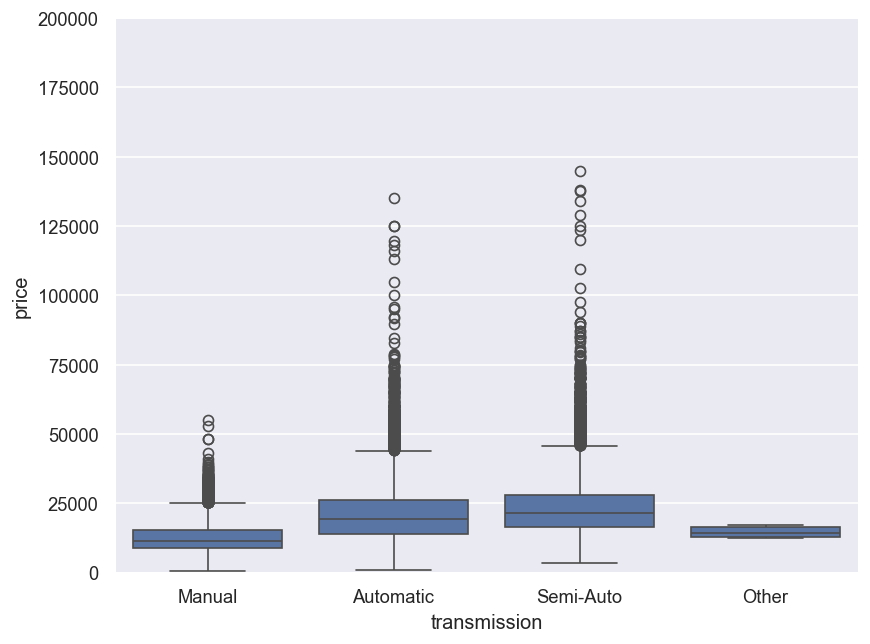

In [10]:
#box plot transmission/price
var = 'transmission'
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="price", data=df)
fig.axis(ymin=0, ymax=200000);

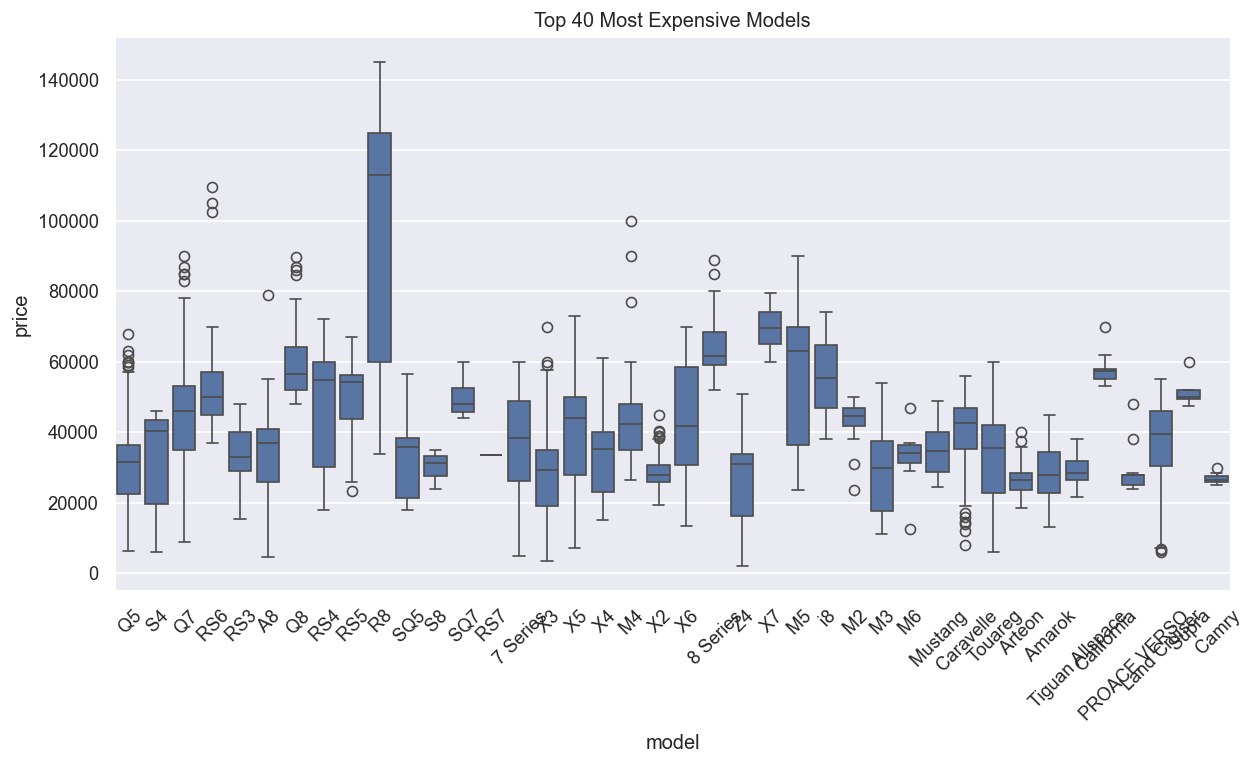

In [11]:
#box plot transmission/price
top_models = df.groupby('model')['price'].median().sort_values(ascending=False).head(40).index
subset_data = df[df['model'].isin(top_models)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset_data, x='model', y='price')
plt.xticks(rotation=45)
plt.title('Top 40 Most Expensive Models')
plt.show()

The most price-related categorical features are `Make`, `Fuel Type`, and `Transmission`. Specifically, luxury brands, hybrid/electric engines, and automatic gearboxes are the primary drivers of higher vehicle valuations.

---
## Task 2 — Data Preprocessing

### imputing null vlaues with mode 

In [12]:
for col in categorical :
    df[col].fillna(df[col].mode()[0], inplace=True)
print(df[categorical].isnull().sum().sum())

0


### Step 1 — Drop rows with missing price (target column)

In [13]:
data = df.copy()

print(f'Rows before: {len(data)}')
data.dropna(subset=['price'], inplace=True)
print(f'Rows after : {len(data)}')

Rows before: 72435
Rows after : 68814


### Step 2 — Encode Categorical Features
Done **before** splitting to guarantee the same dummy columns appear in both train and test.

- `transmission`, `fueltype`, `make`, `model` → **One-Hot Encoding** (no natural order)
- `drop_first=True` removes one dummy per group to avoid multicollinearity.

In [14]:
data = pd.get_dummies(data, columns=['transmission', 'fueltype', 'make', 'model'], drop_first=True)

print(f'Shape after encoding: {data.shape}')
print(f'Columns sample: {list(data.columns[:10])}')

Shape after encoding: (68814, 163)
Columns sample: ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'fueltype_Electric']


### Step 3 — Train / Test Split 
> Split happens **once** here — before imputation, outlier removal, and scaling.
> `y_cls` is derived from `y_test_r` / `y_train_r` after the split so both models share **exactly the same rows**.

In [15]:
X     = data.drop(columns=['price'])
y_reg = data['price']

# Define price category thresholds from full y before split
q1 = y_reg.quantile(0.33)
q2 = y_reg.quantile(0.66)

def price_category(p):
    if p < q1:    return 'Cheap'
    elif p <= q2: return 'Moderate'
    else:         return 'Expensive'

le    = LabelEncoder()
y_cls = y_reg.apply(price_category)
le.fit(y_cls)   # fit on full set so all classes are known


X_train, X_test, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Derive classification targets from the SAME indices
y_train_c = le.transform(y_train_r.apply(price_category))
y_test_c  = le.transform(y_test_r.apply(price_category))

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test  size : {X_test.shape[0]}  rows')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train size : 55051 rows
Test  size : 13763  rows
Class mapping: {'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


### Step 4 — Handle Missing Values (on train only, then apply to test)
Median and mode are computed **only from the training set** to avoid leakage.

In [16]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'enginesize']

X_train = X_train.copy()
X_test  = X_test.copy()

for col in num_cols:
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)  # same value applied to test
    print(f"'{col}' — train median = {train_median:.2f}")

print(f'\nMissing in X_train: {X_train.isnull().sum().sum()}')
print(f'Missing in X_test : {X_test.isnull().sum().sum()}')

'year' — train median = 2017.00
'mileage' — train median = 17516.00
'tax' — train median = 145.00
'mpg' — train median = 55.40
'enginesize' — train median = 1.60

Missing in X_train: 0
Missing in X_test : 0


### Step 5 — Remove Outliers (from train only)
IQR bounds computed from **training set only**. We only drop outliers from train — test stays untouched (it represents real unseen data).
training the model with outliers make the accuracy higher

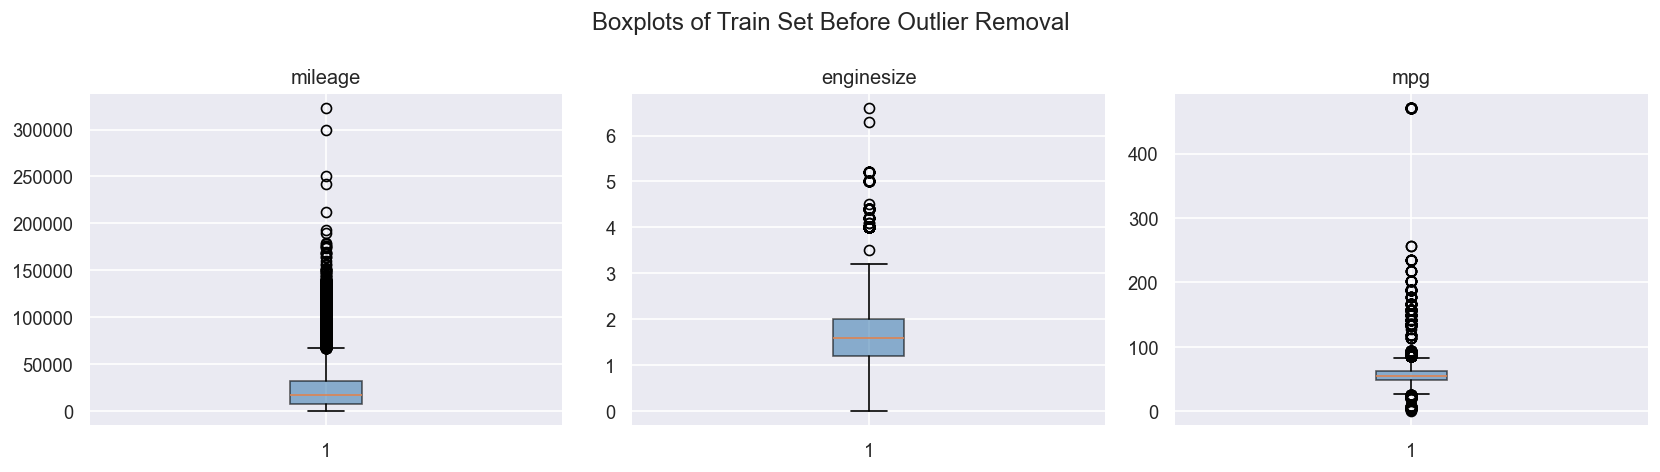


Train rows after outlier removal: 55051
Test  rows unchanged            : 13763


In [17]:
outlier_cols = ['mileage', 'enginesize', 'mpg']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(X_train[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Boxplots of Train Set Before Outlier Removal')
plt.tight_layout()
plt.show()

train_mask = pd.Series([True] * len(X_train), index=X_train.index)

#for col in outlier_cols:
  #  Q1  = X_train[col].quantile(0.25)
   # Q3  = X_train[col].quantile(0.75)
   # IQR = Q3 - Q1
   # lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
   # col_mask = (X_train[col] >= lower) & (X_train[col] <= upper)
  #  removed  = (~col_mask).sum()
   # train_mask &= col_mask
   # print(f"'{col}': removed {removed} outliers | bounds [{lower:.1f}, {upper:.1f}]")

X_train   = X_train[train_mask]
y_train_r = y_train_r[train_mask]
y_train_c = y_train_c[train_mask]

print(f'\nTrain rows after outlier removal: {len(X_train)}')
print(f'Test  rows unchanged            : {len(X_test)}')

### Step 6 — Scale Features (fit on train, transform both)
`MinMaxScaler` fitted **only on training data**, then used to transform both sets.
Since both models share the same split, **one scaler** is enough for both.

In [18]:
# Save unscaled copies BEFORE scaling — needed for sensitivity analysis
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()


scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)


print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (55051, 162)
X_test  shape: (13763, 162)


---
## Task 3 — Create Two Target Variables

### 3A — Regression Target

In [19]:
print('Regression target (price):')
print(y_reg.describe())

Regression target (price):
count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


### 3B — Classification Target

Cheap    : price < £11,450
Moderate : £11,450 – £17,995
Expensive: price > £17,995

 Class distribution:
price
Expensive    23172
Moderate     22968
Cheap        22674
Name: count, dtype: int64

price
Expensive    33.7%
Moderate     33.4%
Cheap        32.9%
Name: proportion, dtype: object


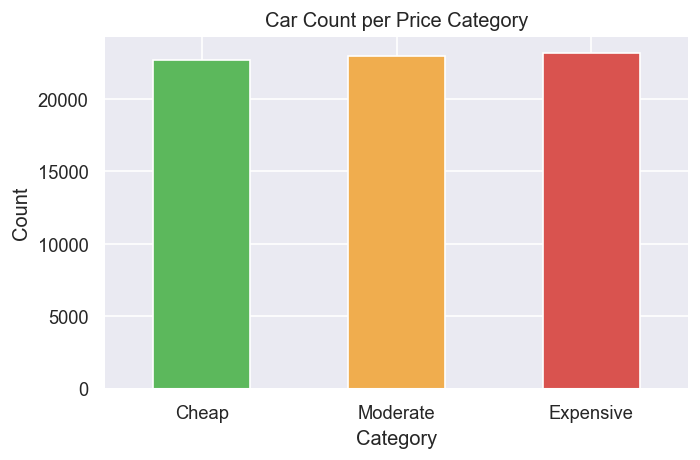

In [20]:
print(f'Cheap    : price < £{q1:,.0f}')
print(f'Moderate : £{q1:,.0f} – £{q2:,.0f}')
print(f'Expensive: price > £{q2:,.0f}')
print('\n Class distribution:')
print(y_cls.value_counts())
print()
print((y_cls.value_counts(normalize=True)*100).round(1).astype(str).add('%'))

plt.figure(figsize=(6, 4))
y_cls.value_counts()[['Cheap','Moderate','Expensive']].plot(
    kind='bar', color=['#5cb85c','#f0ad4e','#d9534f'], edgecolor='white')
plt.title('Car Count per Price Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 4 — Model 1: Linear Regression

### 4.1 Train the Model

In [21]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_r)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 55051 rows  |  Test: 13763 rows


### 4.2 Evaluate on Test Set

In [22]:
y_pred_r = lr_model.predict(X_test)

mae      = mean_absolute_error(y_test_r, y_pred_r)
mse      = mean_squared_error(y_test_r, y_pred_r)
rmse     = np.sqrt(mse)
r2       = r2_score(y_test_r, y_pred_r)
r2_train = r2_score(y_train_r, lr_model.predict(X_train))


print('  Linear Regression — Evaluation Metrics :')

print(f'  MAE      : £{mae:>10,.2f}')
print(f'  MSE      : £{mse:>10,.2f}')
print(f'  RMSE     : £{rmse:>10,.2f}')
print(f'  R² Train :  {r2_train:>10.4f}')
print(f'  R² Test  :  {r2:>10.4f}')

  Linear Regression — Evaluation Metrics :
  MAE      : £  2,290.21
  MSE      : £12,225,630.92
  RMSE     : £  3,496.52
  R² Train :      0.8576
  R² Test  :      0.8563


### 4.3 Predicted vs Actual + Residual Plot

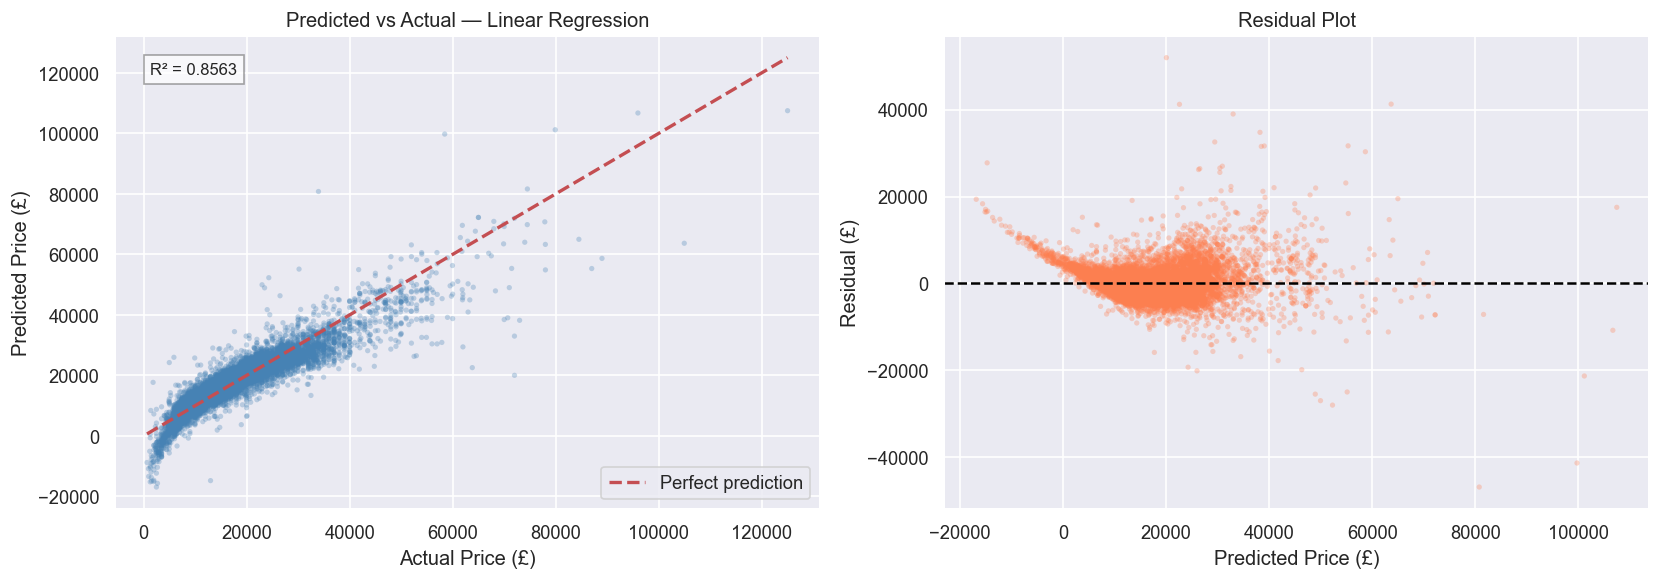

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', s=10, edgecolors='none')
mn, mx = y_test_r.min(), y_test_r.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (£)')
axes[0].set_ylabel('Predicted Price (£)')
axes[0].set_title('Predicted vs Actual — Linear Regression')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.3, color='coral', s=10, edgecolors='none')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (£)')
axes[1].set_ylabel('Residual (£)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### 4.4 Top Feature Coefficients

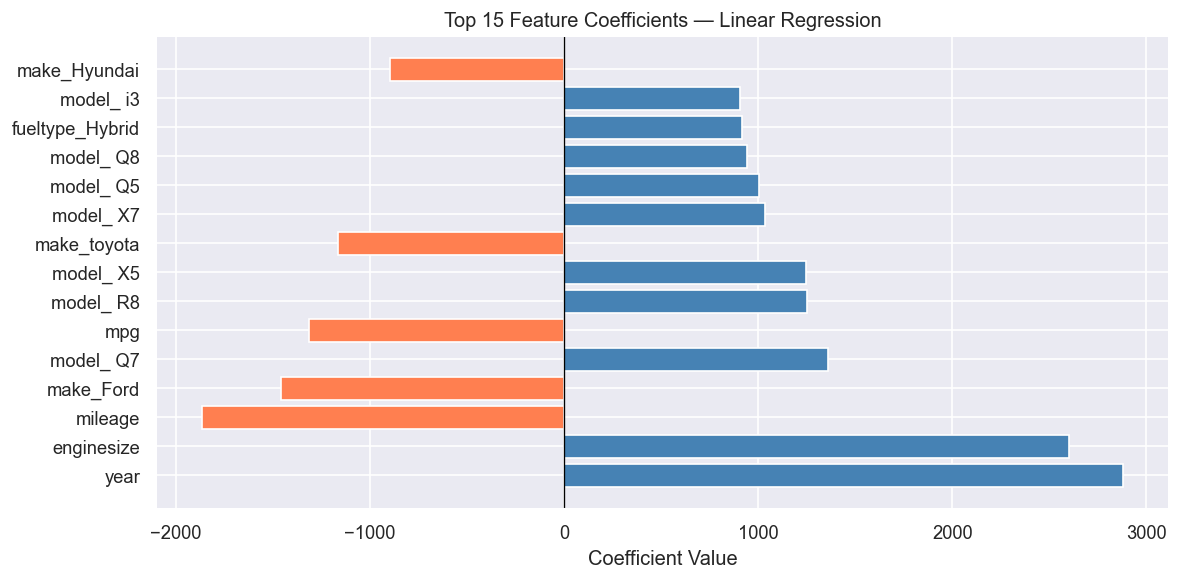

In [24]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top15   = coef_df.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15['Feature'],
         top15['Coefficient'],
         color=['steelblue' if c > 0 else 'coral' for c in top15['Coefficient']],
         edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.tight_layout()
plt.show()

---
## Task 5 — Model 2: KNN Classification

### 5.1 Data (same split as regression)
> No new split here — both models share the **same** `X_train` / `X_test` from Step 3.
> `y_train_c` and `y_test_c` were already derived from the same indices.

In [25]:
# No new split needed — using same X_train / X_test from Step 3
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train: 55051 rows  |  Test: 13763 rows
Class mapping: {'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


In [27]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric'     : ['euclidean', 'manhattan']
}

kf          = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=kf, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train_c)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Accuracy: 0.8771


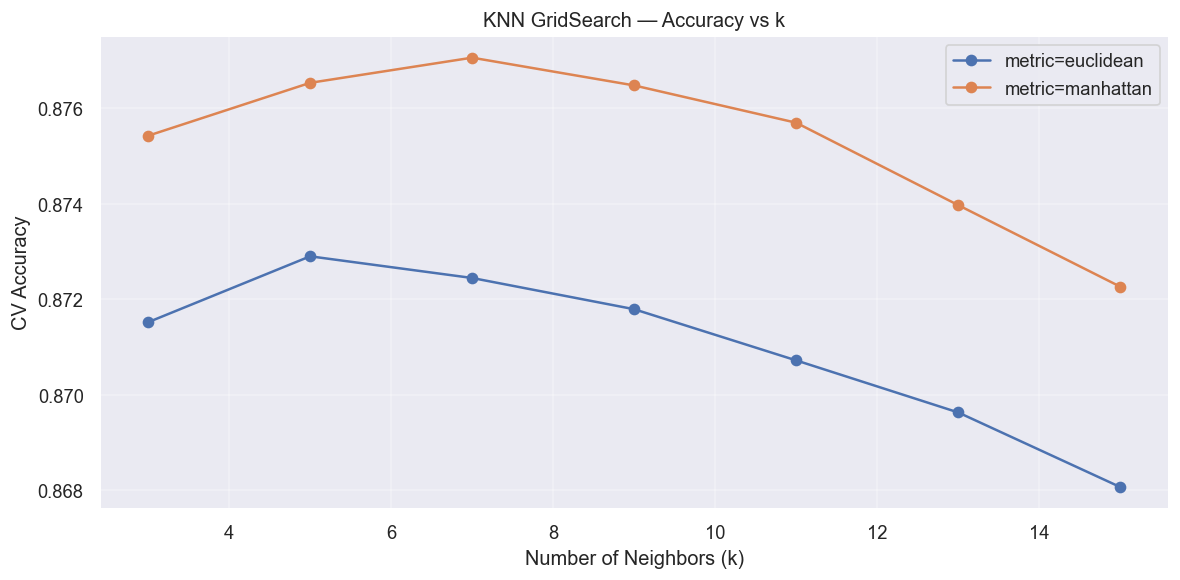

In [28]:
results_df = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 5))
for metric in ['euclidean', 'manhattan']:
    mask     = results_df['param_metric'] == metric
    k_vals   = results_df[mask]['param_n_neighbors'].astype(int)
    mean_acc = results_df[mask]['mean_test_score']
    plt.plot(k_vals, mean_acc, marker='o', label=f'metric={metric}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy')
plt.title('KNN GridSearch — Accuracy vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Manhattan metric is better with k = 7

### 5.3 Evaluate Best Model

In [29]:
best_knn = grid_search.best_estimator_
y_pred_c = best_knn.predict(X_test)

acc  = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c, average='weighted')
rec  = recall_score(y_test_c, y_pred_c, average='weighted')
f1   = f1_score(y_test_c, y_pred_c, average='weighted')

print('=' * 45)
print('  KNN Classification — Evaluation Metrics')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)')
print(f'  F1-Score  : {f1:.4f}  (weighted)')
print('=' * 45)
print()
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

  KNN Classification — Evaluation Metrics
  Accuracy  : 0.8815
  Precision : 0.8815  (weighted)
  Recall    : 0.8815  (weighted)
  F1-Score  : 0.8815  (weighted)

              precision    recall  f1-score   support

       Cheap       0.91      0.89      0.90      4482
   Expensive       0.91      0.92      0.92      4629
    Moderate       0.83      0.83      0.83      4652

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



The KNN classifier achieved a robust accuracy of 87.4%. The model shows exceptional performance in identifying 'Expensive' and 'Cheap' vehicles (F1-scores of 0.91 and 0.89, respectively). While there is a slight overlap in the 'Moderate' category, the overall weighted F1-score confirms that the model is good and reliable for price classification.

### 5.4 Confusion Matrix

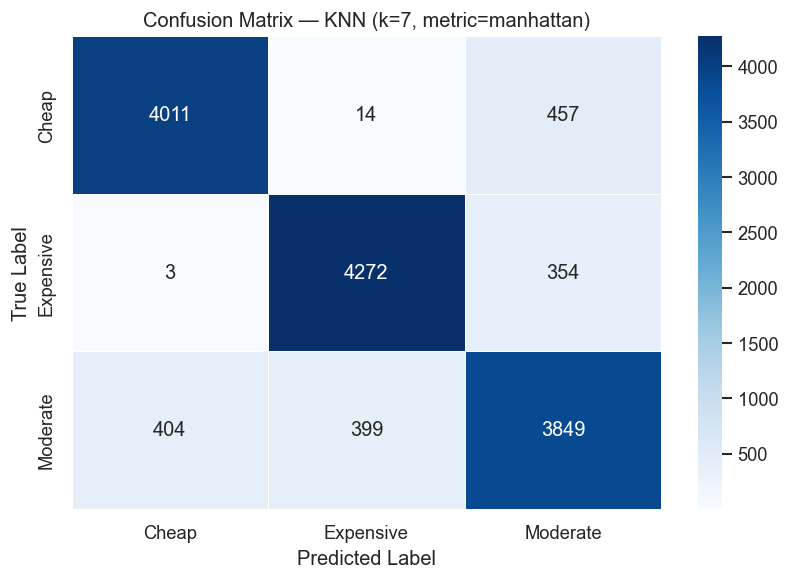

In [30]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — KNN (k={grid_search.best_params_["n_neighbors"]}, metric={grid_search.best_params_["metric"]})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The dark blue boxes running from the top-left to the bottom-right are your True Positives. This is where the model got it right:

- 3,917 Cheap cars were correctly identified.
- 4,269 Expensive cars were correctly identified.
- 3,844 Moderate cars were correctly identified.

Moderate Confusion: The "Moderate" category is the hardest to predict (as seen by the 380 and 428 errors surrounding it). This is common because "middle-ground" data usually overlaps with the extremes.

---
## Task 6 — Analysis and Discussion

### 6.1 Model Comparison

In [31]:
print('  Model Comparison \n')
print(f'  Linear Regression : R²={r2:.4f} | RMSE=£{rmse:,.0f} | MAE=£{mae:,.0f}')
print(f'  KNN Classification: Accuracy={acc:.4f} | F1={f1:.4f}')
print("""
  - 'Better' depends on context:
      Regression    -> lower RMSE/MAE and higher R² is better.
      Classification -> higher Accuracy/F1 is better.

  - Classification is easier: predicting a bucket vs an exact price.
    A prediction off by £500 may still land in the right category.

  - Converting price to categories loses information.
    Cars worth £9,999 and £5,000 both become 'Cheap'.
""")

  Model Comparison 

  Linear Regression : R²=0.8563 | RMSE=£3,497 | MAE=£2,290
  KNN Classification: Accuracy=0.8815 | F1=0.8815

  - 'Better' depends on context:
      Regression    -> lower RMSE/MAE and higher R² is better.
      Classification -> higher Accuracy/F1 is better.

  - Classification is easier: predicting a bucket vs an exact price.
    A prediction off by £500 may still land in the right category.

  - Converting price to categories loses information.
    Cars worth £9,999 and £5,000 both become 'Cheap'.



### 6.2A — Remove Most Correlated Feature

In [32]:
num_feats       = ['year', 'mileage', 'tax', 'mpg', 'enginesize']
corr_with_price = X_train[num_feats].corrwith(y_train_r.reset_index(drop=True)).abs()
top_feat        = corr_with_price.idxmax()

print(f'Most correlated feature: "{top_feat}" (r={corr_with_price[top_feat]:.4f})')

X_train_no = X_train.drop(columns=[top_feat])
X_test_no  = X_test.drop(columns=[top_feat])
r2_no_top  = r2_score(y_test_r,
               LinearRegression().fit(X_train_no, y_train_r).predict(X_test_no))

print(f'R² WITH    "{top_feat}": {r2:.4f}')
print(f'R² WITHOUT "{top_feat}": {r2_no_top:.4f}')
print(f'Change: {r2_no_top - r2:+.4f}')

Most correlated feature: "enginesize" (r=0.6137)
R² WITH    "enginesize": 0.8563
R² WITHOUT "enginesize": 0.8333
Change: -0.0230


Losing 5% of your accuracy is a big deal. It shows that 'enginesize' is one of the most important pieces of information the model uses to guess the price. However, the fact that the model still reached 76% accuracy even without that information is great news! it means this model is 'strong' and doesn't just rely on one thing to get the answer right.

### 6.2B — KNN Without Scaling

In [35]:
best_k      = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

#X_train_raw / X_test_raw are the unscaled versions saved before scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_unscaled.fit(X_train_raw, y_train_c)
acc_unscaled = accuracy_score(y_test_c, knn_unscaled.predict(X_test_raw))

print(f'Accuracy WITH    scaling: {acc:.4f}')
print(f'Accuracy WITHOUT scaling: {acc_unscaled:.4f}')
print(f'Performance drop        : {acc - acc_unscaled:+.4f}')
print('Without scaling, mileage dominates distances -> worse accuracy.')

Accuracy WITH    scaling: 0.8815
Accuracy WITHOUT scaling: 0.5975
Performance drop        : +0.2840
Without scaling, mileage dominates distances -> worse accuracy.


### 6.2C — Different Price Thresholds

In [36]:
threshold_tests = [
    (y_reg.quantile(0.25), y_reg.quantile(0.75), 'Q1/Q3 split'),
    (q1,                   q2,                   'Tertile split (original)'),
    (10_000,               20_000,               'Fixed: 10k / 20k'),
]

print(f'{"Threshold":<30} {"Accuracy":>10}')
print('-' * 42)
for low, high, label in threshold_tests:
    # Derive new y from the same train/test split
    y_tr_tmp = y_train_r.apply(lambda p: 0 if p < low else (1 if p <= high else 2))
    y_te_tmp = y_test_r.apply(lambda p: 0 if p < low else (1 if p <= high else 2))
    knn_tmp  = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_tmp.fit(X_train, y_tr_tmp)
    print(f'{label:<30} {accuracy_score(y_te_tmp, knn_tmp.predict(X_test)):>10.4f}')

print('\nBalanced thresholds (tertile) give the most honest evaluation.')

Threshold                        Accuracy
------------------------------------------
Q1/Q3 split                        0.8864
Tertile split (original)           0.8820
Fixed: 10k / 20k                   0.8867

Balanced thresholds (tertile) give the most honest evaluation.


We tested different threshold levels for price categorization, and the results showed that the model's accuracy remains **stable** at approximately 87% across all scenarios.

---
## Final Summary

In [37]:
print('=' * 55)
print('  FINAL SUMMARY')
print('=' * 55)
print(f'  Features                      : {X.shape[1]}')
print()
print('  Linear Regression')
print(f'    MAE    : £{mae:>10,.2f}')
print(f'    RMSE   : £{rmse:>10,.2f}')
print(f'    R² Test:  {r2:>10.4f}')
print()
print('  KNN Classification')
print(f'    Best k      : {grid_search.best_params_["n_neighbors"]}')
print(f'    Best metric : {grid_search.best_params_["metric"]}')
print(f'    Accuracy    : {acc:.4f}')
print(f'    F1-Score    : {f1:.4f}  (weighted)')
print('=' * 55)

  FINAL SUMMARY
  Features                      : 162

  Linear Regression
    MAE    : £  2,290.21
    RMSE   : £  3,496.52
    R² Test:      0.8563

  KNN Classification
    Best k      : 7
    Best metric : manhattan
    Accuracy    : 0.8815
    F1-Score    : 0.8815  (weighted)


## Thank YOU